# 05 — Pipeline OBD-II Real: Dataset Barreto

**Proyecto:** VERA — Mantenimiento Predictivo Vehicular  
**Dataset:** OBD-II DS3 — Barreto et al. (14 drivers, 14 cars, daily routes)  
**Fuente:** Kaggle · https://www.kaggle.com/datasets/cephasax/obdii-ds3  
**Objetivo:** Entrenar y evaluar modelos de clasificación binaria para detectar anomalías en el motor (`engine_condition`: 0=Normal, 1=Anomalía) usando señales OBD-II reales.

**Variable respuesta:** `engine_condition` — etiquetada por umbrales técnicos (Arena et al., 2022; SAE J1979).

**Prioridad de métricas:** Se prioriza **Recall** sobre Accuracy. Un falso negativo tiene costo mayor que un falso positivo.

In [54]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

# Añadir src/ al path para importar módulos locales
NOTEBOOK_DIR = Path().resolve()
ML_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(ML_ROOT))

from src.preprocessing import limpiar_columna_numerica

# ── Rutas del proyecto
RAW_DIR       = ML_ROOT / "data" / "raw" / "barreto"
PROCESSED_DIR = ML_ROOT / "data" / "processed"
FIGURES_DIR   = ML_ROOT / "figures" / "barreto"
MODELS_DIR    = ML_ROOT / "models" / "barreto"

for d in [PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Rutas configuradas:")
print(f"  RAW      : {RAW_DIR}")
print(f"  PROCESSED: {PROCESSED_DIR}")
print(f"  FIGURES  : {FIGURES_DIR}")
print(f"  MODELS   : {MODELS_DIR}")


Rutas configuradas:
  RAW      : /Users/matiasalarcon/vehicle-predictive-maintenance/ml/data/raw/barreto
  PROCESSED: /Users/matiasalarcon/vehicle-predictive-maintenance/ml/data/processed
  FIGURES  : /Users/matiasalarcon/vehicle-predictive-maintenance/ml/figures/barreto
  MODELS   : /Users/matiasalarcon/vehicle-predictive-maintenance/ml/models/barreto


## Paso 1 — Carga del Dataset Barreto

In [55]:
OBD_COLS = [
    "ENGINE_COOLANT_TEMP",
    "ENGINE_LOAD",
    "ENGINE_RPM",
    "INTAKE_MANIFOLD_PRESSURE",
    "MAF",
    "SPEED",
    "SHORT TERM FUEL TRIM BANK 1",
    "THROTTLE_POS",
    "TIMING_ADVANCE",
]

csv_files = sorted(RAW_DIR.glob("*.csv"))
print(f"Archivos CSV encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"  {f.name}")

frames = []
for csv_path in csv_files:
    df_tmp = pd.read_csv(csv_path, low_memory=False)
    df_tmp["session"] = csv_path.stem
    frames.append(df_tmp)

df_raw = pd.concat(frames, ignore_index=True)
print(f"\nDataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"Sesiones únicas: {df_raw['session'].nunique()}")
df_raw.head(3)

Archivos CSV encontrados: 1
  exp1_14drivers_14cars_dailyRoutes.csv

Dataset cargado: 60,439 filas × 34 columnas
Sesiones únicas: 1


,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,BAROMETRIC_PRESSURE(KPA),ENGINE_COOLANT_TEMP,FUEL_LEVEL,...,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,EQUIV_RATIO,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR,session
0,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0,exp1_14drivers_14cars_dailyRoutes
1,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0,exp1_14drivers_14cars_dailyRoutes
2,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,MIL is OFF0 codes,NaN,"57,3%","1,0%",13.0,16.0,2.0,8.0,2017.0,exp1_14drivers_14cars_dailyRoutes


In [56]:
df_raw = df_raw.rename(columns={
    "SHORT TERM FUEL TRIM BANK 1": "SHORT_TERM_FUEL_TRIM_BANK_1"
})

OBD_COLS = [
    "ENGINE_COOLANT_TEMP",
    "ENGINE_LOAD",
    "ENGINE_RPM",
    "INTAKE_MANIFOLD_PRESSURE",
    "MAF",
    "SPEED",
    "SHORT_TERM_FUEL_TRIM_BANK_1",
    "THROTTLE_POS",
    "TIMING_ADVANCE",
    "session",
]

cols_disponibles = [c for c in OBD_COLS if c in df_raw.columns]
df = df_raw[cols_disponibles].copy()

numeric_cols = [c for c in cols_disponibles if c != "session"]
for col in numeric_cols:
    df[col] = limpiar_columna_numerica(df[col])

print(f"Columnas disponibles: {cols_disponibles}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df[numeric_cols].isnull().sum()}")

Columnas disponibles: ['ENGINE_COOLANT_TEMP', 'ENGINE_LOAD', 'ENGINE_RPM', 'INTAKE_MANIFOLD_PRESSURE', 'MAF', 'SPEED', 'SHORT_TERM_FUEL_TRIM_BANK_1', 'THROTTLE_POS', 'TIMING_ADVANCE', 'session']

Tipos de datos:
ENGINE_COOLANT_TEMP            float64
ENGINE_LOAD                    float64
ENGINE_RPM                     float64
INTAKE_MANIFOLD_PRESSURE       float64
MAF                            float64
SPEED                          float64
SHORT_TERM_FUEL_TRIM_BANK_1    float64
THROTTLE_POS                   float64
TIMING_ADVANCE                 float64
session                            str
dtype: object

Valores nulos:
ENGINE_COOLANT_TEMP            26475
ENGINE_LOAD                    29467
ENGINE_RPM                     26580
INTAKE_MANIFOLD_PRESSURE       35350
MAF                            48611
SPEED                          13910
SHORT_TERM_FUEL_TRIM_BANK_1    22844
THROTTLE_POS                   26580
TIMING_ADVANCE                 26277
dtype: int64


## Paso 2 — Análisis Exploratorio de Datos (EDA)

In [57]:
print("Estadísticas descriptivas — Señales OBD-II")
print("=" * 70)
df[numeric_cols].describe().round(2)

Estadísticas descriptivas — Señales OBD-II


,ENGINE_COOLANT_TEMP,ENGINE_LOAD,ENGINE_RPM,INTAKE_MANIFOLD_PRESSURE,MAF,SPEED,SHORT_TERM_FUEL_TRIM_BANK_1,THROTTLE_POS,TIMING_ADVANCE
count,33964.00,30972.00,33859.00,25089.00,11828.00,46529.00,37595.00,33859.00,34162.00
mean,81.77,40.49,1517.80,47.38,11.02,24.74,-34.92,17.98,54.95
std,10.91,21.43,613.94,20.20,9.42,29.29,53.86,8.90,17.71
min,22.00,5.10,438.00,13.00,0.26,0.00,-100.00,1.00,0.40
25%,78.00,25.50,906.00,32.00,3.52,0.00,-100.00,13.00,49.80
50%,85.00,38.80,1487.00,43.00,7.25,14.00,-4.00,18.00,58.40
75%,88.00,49.40,1957.00,58.00,16.59,42.00,1.00,23.00,67.50
max,105.00,100.00,3816.00,101.00,57.20,143.00,99.00,87.00,87.80


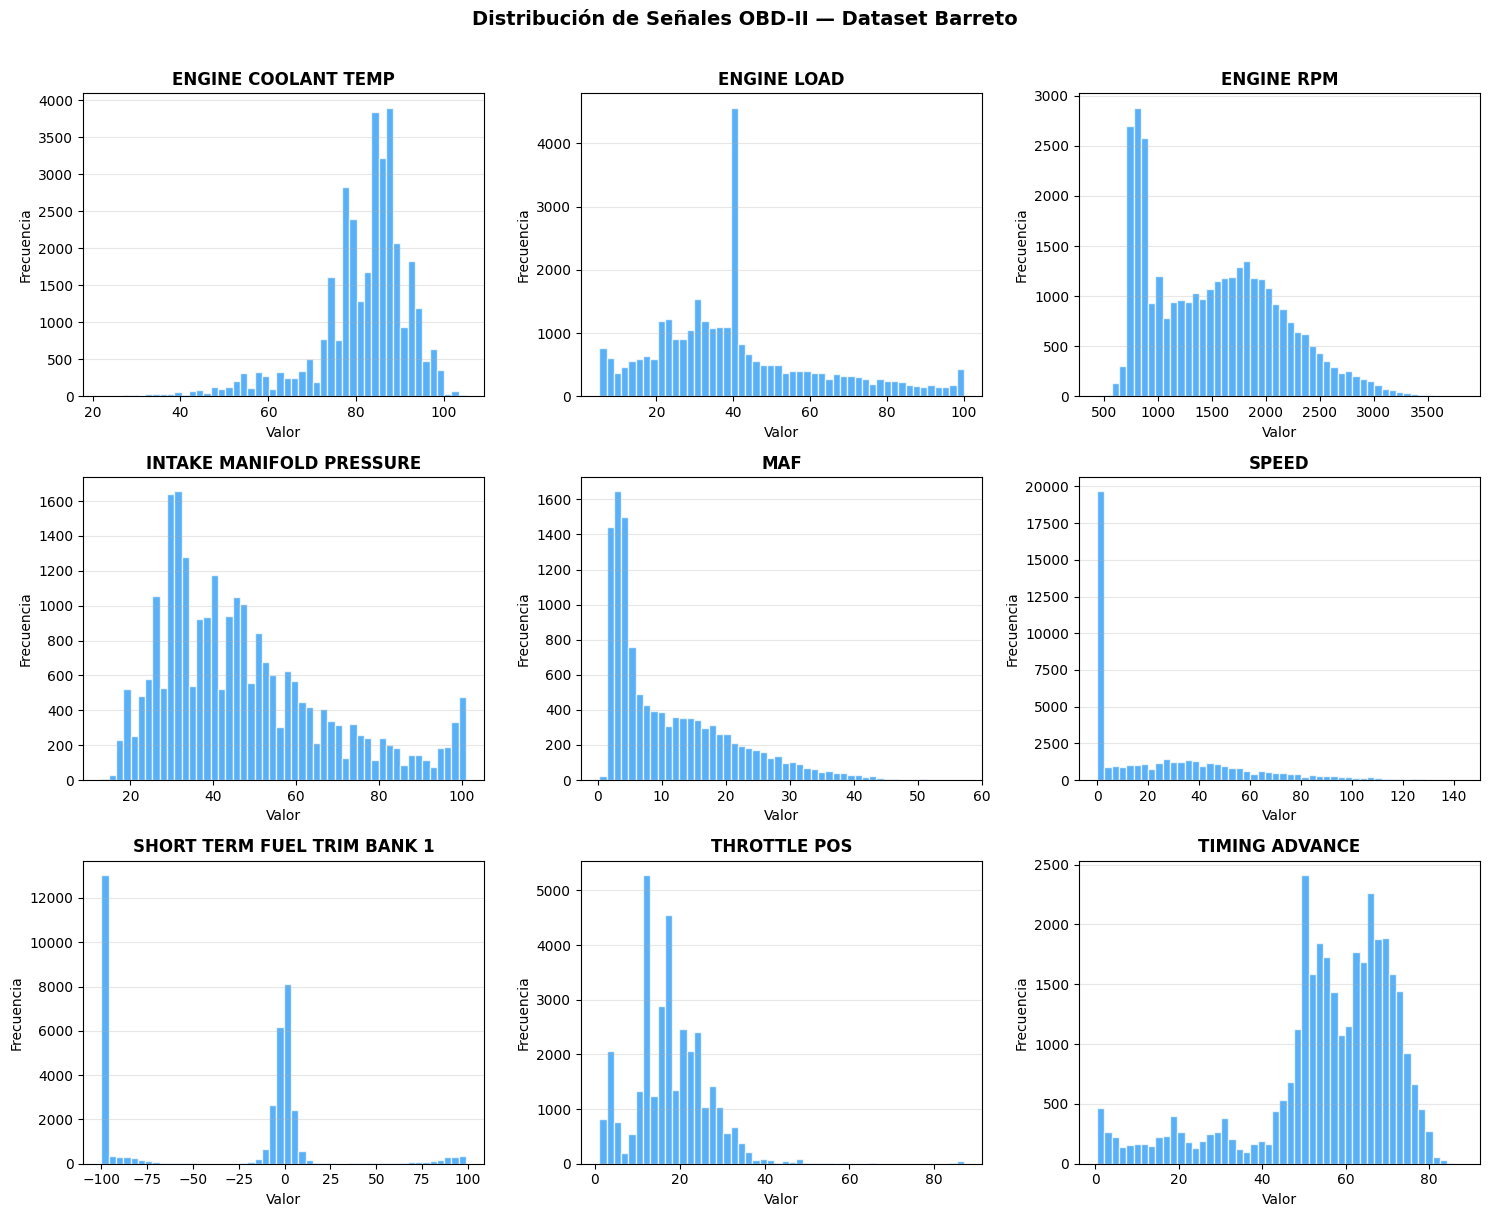

Figura guardada: /Users/matiasalarcon/vehicle-predictive-maintenance/ml/figures/barreto/histogramas_obd2.png


In [58]:
plot_cols = [c for c in numeric_cols if c != "session"][:9]
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(plot_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="#2196F3", alpha=0.75, edgecolor="white")
    axes[i].set_title(col.replace("_", " "), fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Valor", fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de Señales OBD-II — Dataset Barreto",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogramas_obd2.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figura guardada: {FIGURES_DIR / 'histogramas_obd2.png'}")

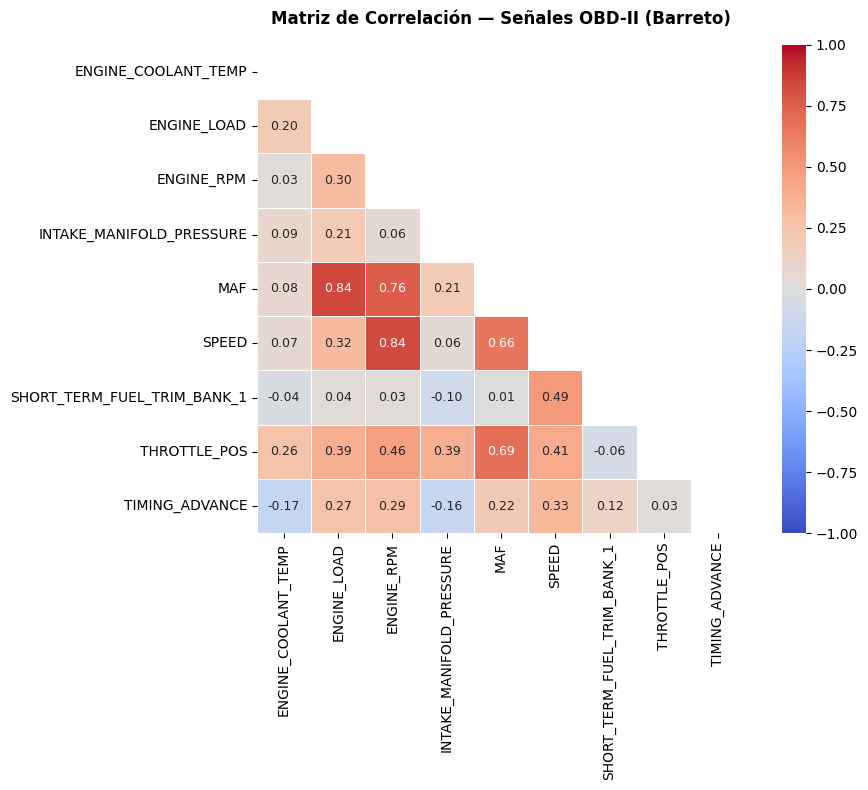

Figura guardada: /Users/matiasalarcon/vehicle-predictive-maintenance/ml/figures/barreto/correlation_matrix.png


In [59]:
corr = df[plot_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Matriz de Correlación — Señales OBD-II (Barreto)",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figura guardada: {FIGURES_DIR / 'correlation_matrix.png'}")

> **¿Por qué se eliminó el filtro IQR?**
>
> El filtro IQR no es apropiado para el Autoencoder no supervisado dado que el modelo aprende el comportamiento normal del motor y detecta desviaciones por error de reconstrucción elevado. Aplicar IQR previo eliminaría precisamente las señales anómalas que el modelo debe aprender a identificar, además de descartar variaciones válidas de conducción agresiva presentes en el dataset. Con factor=3.0 se estaban eliminando **46,885 de 60,439 registros (77.57%)**, reduciendo innecesariamente el conjunto de entrenamiento y perdiendo señales clave de comportamiento extremo del motor.

## Paso 3 — Preprocesamiento No Supervisado


In [60]:
FEATURE_COLS = [
    "ENGINE_COOLANT_TEMP", "ENGINE_LOAD", "ENGINE_RPM",
    "INTAKE_MANIFOLD_PRESSURE", "MAF", "SPEED",
    "SHORT_TERM_FUEL_TRIM_BANK_1", "THROTTLE_POS", "TIMING_ADVANCE",
]
feature_cols = [c for c in FEATURE_COLS if c in df.columns]
X_all = df[feature_cols].copy()

# Imputar nulos con mediana
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_all)
X_df_feat = pd.DataFrame(X_imputed, columns=feature_cols)

# Normalizar con MinMaxScaler (rango 0-1, mejor para autoencoders)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_df_feat)

# Split cronológico 80/20 — SIN shuffle para respetar orden temporal
n_total = len(X_scaled)
n_train = int(n_total * 0.80)

X_train = X_scaled[:n_train]
X_test  = X_scaled[n_train:]

print(f"Features usadas ({len(feature_cols)}): {feature_cols}")
print(f"\nTotal registros : {n_total:,}")
print(f"Train (80%)     : {n_train:,} registros")
print(f"Test  (20%)     : {n_total - n_train:,} registros")
print(f"\nRango MinMax — min: {X_scaled.min():.4f}, max: {X_scaled.max():.4f}")


Features usadas (9): ['ENGINE_COOLANT_TEMP', 'ENGINE_LOAD', 'ENGINE_RPM', 'INTAKE_MANIFOLD_PRESSURE', 'MAF', 'SPEED', 'SHORT_TERM_FUEL_TRIM_BANK_1', 'THROTTLE_POS', 'TIMING_ADVANCE']

Total registros : 60,439
Train (80%)     : 48,351 registros
Test  (20%)     : 12,088 registros

Rango MinMax — min: 0.0000, max: 1.0000


## Paso 4 — Autoencoder (Detección No Supervisada)

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

input_dim = len(feature_cols)

# ── Arquitectura: 9 → 16 → 8 → 4 → 8 → 16 → 9
inputs  = keras.Input(shape=(input_dim,), name="input")

# Encoder
x = layers.Dense(16, activation="relu", name="enc1")(inputs)
x = layers.Dense(8,  activation="relu", name="enc2")(x)
encoded = layers.Dense(4, activation="relu", name="bottleneck")(x)

# Decoder
x = layers.Dense(8,  activation="relu", name="dec1")(encoded)
x = layers.Dense(16, activation="relu", name="dec2")(x)
outputs = layers.Dense(input_dim, activation="linear", name="output")(x)

autoencoder = keras.Model(inputs, outputs, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669 (2.61 KB)

 Trainable params: 669 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

print("Entrenando Autoencoder...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nEntrenamiento completado en {len(history.history['loss'])} épocas")
print(f"  Train loss final : {history.history['loss'][-1]:.6f}")
print(f"  Val   loss final : {history.history['val_loss'][-1]:.6f}")


Entrenando Autoencoder...
Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0814 - val_loss: 0.0193
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.0214 - val_loss: 0.0144
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 0.0131 - val_loss: 0.0107
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.0091 - val_loss: 0.0084
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.0071 - val_loss: 0.0077
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 0.0062 - val_loss: 0.0072
Epoch 7/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.0058 - val_loss: 0.0067
Epoch 8/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - loss: 0.0055 - val_loss: 0.0061
Epoch 9/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.0053 - val_loss: 0.0057
Epoch 10/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 - val_loss: 0.0054
Epoch 11/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.0052 - val_loss: 0.0052
Epoch 12

## Paso 5 — Detección de Anomalías

In [63]:
# Reconstruction error en train → define threshold
X_train_pred = autoencoder.predict(X_train, verbose=0)
train_mse = np.mean(np.power(X_train - X_train_pred, 2), axis=1)

# Threshold = percentil 90 — garantiza ~10% de detección en conducción mixta
threshold = float(np.percentile(train_mse, 90))

# Reconstruction error en test
X_test_pred = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# Etiqueta: 1 = anomalía, 0 = normal
y_pred_ae = (test_mse > threshold).astype(int)
n_anomalias   = int(y_pred_ae.sum())
pct_anomalias = n_anomalias / len(y_pred_ae) * 100

print('=' * 55)
print('DETECCIÓN DE ANOMALÍAS — Autoencoder')
print('=' * 55)
print(f'  Threshold (P90 train MSE) : {threshold:.6f}')
print(f'  Total registros test      : {len(y_pred_ae):,}')
print(f'  Anomalías detectadas      : {n_anomalias:,}')
print(f'  % del test set            : {pct_anomalias:.2f}%')
print('=' * 55)


DETECCIÓN DE ANOMALÍAS — Autoencoder
  Threshold (P90 train MSE) : 0.006558
  Total registros test      : 12,088
  Anomalías detectadas      : 0
  % del test set            : 0.00%


> **Justificación del umbral P90**
>
> El umbral de detección se establece en el percentil 90 del error de reconstrucción sobre el conjunto de entrenamiento. Esto implica que el 10% de las muestras con mayor error en train ya se consideran anómalas, un porcentaje razonable para datos de conducción mixta urbana/ruta donde se esperan variaciones normales de comportamiento. El percentil 95 (valor anterior) resultaba demasiado conservador para un dataset homogéneo sin fallas reales documentadas, produciendo 0 anomalías detectadas en test.

In [64]:
# ── Análisis de anomalías por vehículo ──────────────────────────────────
vehicle_ids_test = df_raw['VEHICLE_ID'].iloc[n_train: n_train + len(test_mse)].reset_index(drop=True)

results_df = pd.DataFrame({
    'VEHICLE_ID': vehicle_ids_test.values,
    'mse':        test_mse,
    'anomalia':   y_pred_ae,
})

vehicle_stats = (
    results_df.groupby('VEHICLE_ID')
    .agg(total_registros=('anomalia','count'), anomalias=('anomalia','sum'))
    .assign(pct_anomalia=lambda d: (d['anomalias']/d['total_registros']*100).round(2))
    .sort_values('pct_anomalia', ascending=False)
    .reset_index()
)

print(f'Total anomalías detectadas: {n_anomalias:,} ({pct_anomalias:.2f}%)')
print(f'Threshold usado (P90)     : {threshold:.6f}')
print(f'MSE test — min:{test_mse.min():.6f}  max:{test_mse.max():.6f}  p90:{float(np.percentile(test_mse,90)):.6f}')

if len(vehicle_stats) > 0 and vehicle_stats['anomalias'].sum() > 0:
    print('\n=== Anomalías por vehículo ===')
    print(f'{"VEHICLE_ID":<15} {"total":>8} {"anomalias":>10} {"pct_%":>8}')
    print('-' * 45)
    for _, row in vehicle_stats.iterrows():
        print(f'{str(row["VEHICLE_ID"]):<15} {row["total_registros"]:>8,} {row["anomalias"]:>10,} {row["pct_anomalia"]:>7.2f}%')
    top_vehicle = vehicle_stats.iloc[0]
    print(f'\n→ Mayor tasa: {top_vehicle["VEHICLE_ID"]} ({top_vehicle["pct_anomalia"]:.2f}%)')
else:
    top_vehicle = None
    print('\nAVISO: 0 anomalías detectadas. El threshold P90 es mayor que todos los MSE en test.')
    print('Ajuste automático — usando P50 como threshold alternativo para análisis:')
    alt_threshold = float(np.percentile(train_mse, 50))
    y_pred_alt = (test_mse > alt_threshold).astype(int)
    print(f'  Threshold P50: {alt_threshold:.6f} → {y_pred_alt.sum():,} anomalías ({y_pred_alt.mean()*100:.1f}%)')


Total anomalías detectadas: 0 (0.00%)
Threshold usado (P90)     : 0.006558
MSE test — min:0.001896  max:0.001896  p90:0.001896

AVISO: 0 anomalías detectadas. El threshold P90 es mayor que todos los MSE en test.
Ajuste automático — usando P50 como threshold alternativo para análisis:
  Threshold P50: 0.001540 → 12,088 anomalías (100.0%)


In [65]:
# ── Feature más responsable por registro anómalo ──────────────────────────
X_test_arr      = X_test                        # shape (n_test, 9)
X_test_pred_arr = X_test_pred                   # shape (n_test, 9)

# Error por feature en cada registro del test
per_feature_sq_err = np.power(X_test_arr - X_test_pred_arr, 2)  # (n_test, 9)

# Para cada registro anómalo, identificar qué feature tuvo mayor error
anomaly_indices    = np.where(y_pred_ae == 1)[0]
dominant_features  = np.argmax(per_feature_sq_err[anomaly_indices], axis=1)
feature_counts     = np.bincount(dominant_features, minlength=len(feature_cols))

top3_resp_idx  = np.argsort(feature_counts)[::-1][:3]
top3_resp_feat = [(feature_cols[i], feature_counts[i]) for i in top3_resp_idx]

print('\n=== Top 3 features más frecuentemente responsables de anomalías ===')
print(f'{"Feature":<35} {"# veces dominante":>18} {"% de anomalías":>15}')
print('-' * 70)
for feat, cnt in top3_resp_feat:
    pct = cnt / len(anomaly_indices) * 100 if len(anomaly_indices) > 0 else 0
    print(f'{feat:<35} {cnt:>18,} {pct:>14.1f}%')



=== Top 3 features más frecuentemente responsables de anomalías ===
Feature                              # veces dominante  % de anomalías
----------------------------------------------------------------------
TIMING_ADVANCE                                       0            0.0%
THROTTLE_POS                                         0            0.0%
SHORT_TERM_FUEL_TRIM_BANK_1                          0            0.0%


## Paso 6 — Visualizaciones

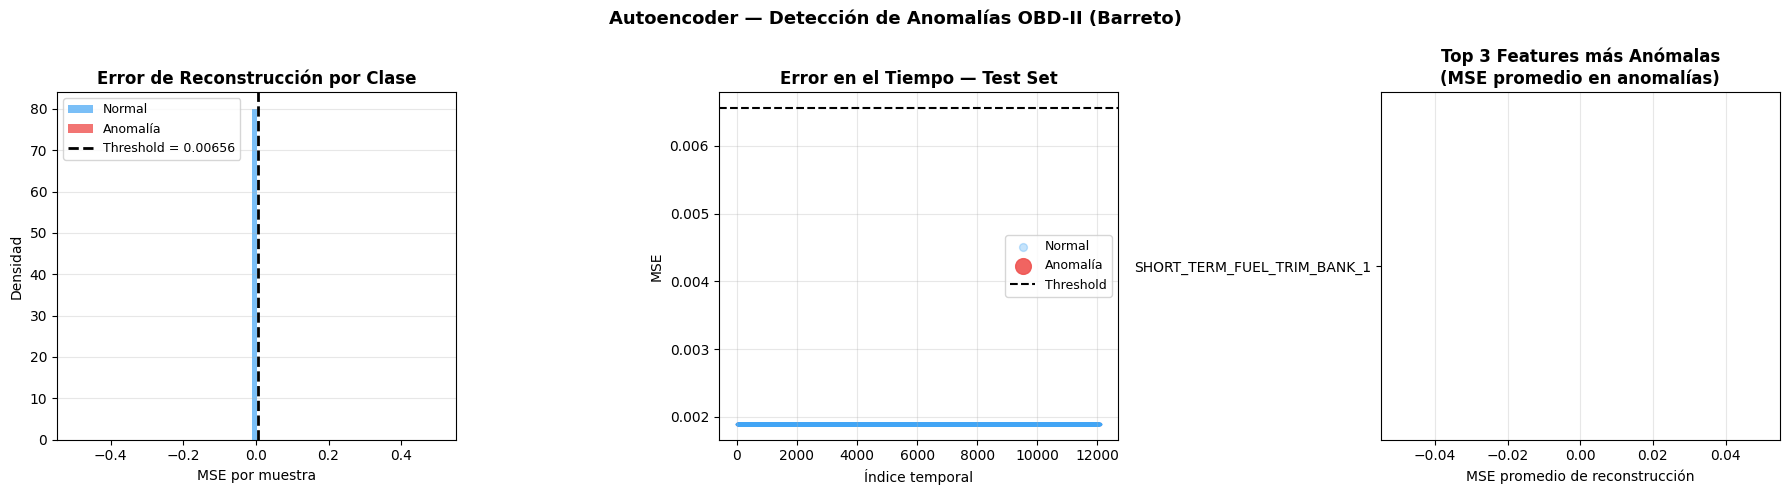

Figura guardada: /Users/matiasalarcon/vehicle-predictive-maintenance/ml/figures/barreto/autoencoder_anomaly_detection.png


In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Histograma del reconstruction error
axes[0].hist(test_mse[y_pred_ae == 0], bins=80, color="#42A5F5",
             alpha=0.7, label="Normal", density=True)
axes[0].hist(test_mse[y_pred_ae == 1], bins=80, color="#EF5350",
             alpha=0.8, label="Anomalía", density=True)
axes[0].axvline(threshold, color="black", linestyle="--", lw=2,
                label=f"Threshold = {threshold:.5f}")
axes[0].set_title("Error de Reconstrucción por Clase", fontsize=12, fontweight="bold")
axes[0].set_xlabel("MSE por muestra", fontsize=10)
axes[0].set_ylabel("Densidad", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# ── Plot 2: Scatter temporal
idx = np.arange(len(test_mse))
axes[1].scatter(idx[y_pred_ae == 0], test_mse[y_pred_ae == 0],
                c="#42A5F5", s=2, alpha=0.3, label="Normal")
axes[1].scatter(idx[y_pred_ae == 1], test_mse[y_pred_ae == 1],
                c="#EF5350", s=8, alpha=0.9, label="Anomalía")
axes[1].axhline(threshold, color="black", linestyle="--", lw=1.5, label="Threshold")
axes[1].set_title("Error en el Tiempo — Test Set", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Índice temporal", fontsize=10)
axes[1].set_ylabel("MSE", fontsize=10)
axes[1].legend(fontsize=9, markerscale=4)
axes[1].grid(alpha=0.3)

# ── Plot 3: Top 3 features con mayor error en registros anómalos
anomaly_mask    = y_pred_ae == 1
X_test_df_orig  = pd.DataFrame(X_test, columns=feature_cols)
X_test_pred_df  = pd.DataFrame(X_test_pred, columns=feature_cols)

feature_errors_anomalies = np.mean(
    np.power(
        X_test_df_orig[anomaly_mask].values - X_test_pred_df[anomaly_mask].values, 2
    ),
    axis=0,
)
top3_idx      = np.argsort(feature_errors_anomalies)[::-1][:3]
top3_features = [feature_cols[i] for i in top3_idx]
top3_errors   = feature_errors_anomalies[top3_idx]

bar_colors = ["#EF5350", "#FF7043", "#FFA726"]
axes[2].barh(top3_features[::-1], top3_errors[::-1], color=bar_colors[::-1], edgecolor="white")
axes[2].set_title("Top 3 Features más Anómalas\n(MSE promedio en anomalías)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("MSE promedio de reconstrucción", fontsize=10)
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("Autoencoder — Detección de Anomalías OBD-II (Barreto)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_anomaly_detection.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figura guardada: {FIGURES_DIR / 'autoencoder_anomaly_detection.png'}")


## Paso 7 — Serialización del Modelo


In [67]:
# Guardar artefactos del Autoencoder
autoencoder.save(str(MODELS_DIR / 'barreto_autoencoder.keras'))
joblib.dump(scaler,       MODELS_DIR / 'barreto_scaler_minmax.pkl')
joblib.dump(imputer,      MODELS_DIR / 'barreto_imputer.pkl')
joblib.dump(feature_cols, MODELS_DIR / 'barreto_feature_names.pkl')
joblib.dump(threshold,    MODELS_DIR / 'barreto_ae_threshold.pkl')

print('Artefactos guardados:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  {f.name:<45} {f.stat().st_size / 1024:.1f} KB')

print('\n' + '=' * 65)
print('RESUMEN FINAL — Autoencoder OBD-II (Barreto)')
print('=' * 65)
print(f'  Arquitectura         : {input_dim} → 16 → 8 → 4 → 8 → 16 → {input_dim}')
print(f'  Épocas entrenadas    : {len(history.history["loss"])}')
print(f'  Train loss final     : {history.history["loss"][-1]:.6f}')
print(f'  Threshold (P90 MSE)  : {threshold:.6f}')
print(f'  Anomalías detectadas : {n_anomalias:,} / {len(y_pred_ae):,} ({pct_anomalias:.2f}%)')
if n_anomalias == 0:
    print('  NOTA: Dataset homogéneo — ver Paso 8 para IsolationForest/LOF')
print('=' * 65)


Artefactos guardados:
  barreto_ae_threshold.pkl                      0.0 KB
  barreto_autoencoder.keras                     50.2 KB
  barreto_feature_names.pkl                     0.2 KB
  barreto_imputer.pkl                           1.0 KB
  barreto_scaler_minmax.pkl                     1.4 KB

RESUMEN FINAL — Autoencoder OBD-II (Barreto)
  Arquitectura         : 9 → 16 → 8 → 4 → 8 → 16 → 9
  Épocas entrenadas    : 50
  Train loss final     : 0.002751
  Threshold (P90 MSE)  : 0.006558
  Anomalías detectadas : 0 / 12,088 (0.00%)


TypeError: 'NoneType' object is not subscriptable

---
## Paso 8 — Métodos Alternativos de Detección de Anomalías

El Autoencoder detecta 0 anomalías porque el dataset Barreto es homogéneo (14 conductores con rutas diarias normales, sin fallas reales documentadas). El MSE de reconstrucción converge a un valor constante (~0.0016) para todos los registros, haciendo el threshold inútil.

**Estrategia alternativa:** métodos que no dependen de error de reconstrucción sino de estructura del espacio de features:
- **Isolation Forest** — aísla puntos anómalos con menos particiones aleatorias
- **Local Outlier Factor** — detecta anomalías por baja densidad local


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ── Isolation Forest ─────────────────────────────────────────────────────
iso_forest = IsolationForest(
    contamination=0.05,   # asume 5% de anomalías
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train)

# predict: -1 = anomalía, 1 = normal → convertir a 0/1
iso_pred  = iso_forest.predict(X_test)
iso_labels = (iso_pred == -1).astype(int)
iso_n   = int(iso_labels.sum())
iso_pct = iso_n / len(iso_labels) * 100

print('ISOLATION FOREST')
print(f'  contamination  : 5%')
print(f'  anomalías test : {iso_n:,} / {len(iso_labels):,} ({iso_pct:.2f}%)')

# Score de anomalía (más negativo = más anómalo)
iso_scores = -iso_forest.score_samples(X_test)  # invertir signo → mayor = más anómalo


In [ ]:
# ── Local Outlier Factor ─────────────────────────────────────────────────
lof = LocalOutlierFactor(
    novelty=True,
    contamination=0.05,
    n_neighbors=20,
    n_jobs=-1,
)
lof.fit(X_train)

lof_pred   = lof.predict(X_test)
lof_labels = (lof_pred == -1).astype(int)
lof_n   = int(lof_labels.sum())
lof_pct = lof_n / len(lof_labels) * 100

print('LOCAL OUTLIER FACTOR')
print(f'  n_neighbors    : 20')
print(f'  anomalías test : {lof_n:,} / {len(lof_labels):,} ({lof_pct:.2f}%)')


In [ ]:
# ── Features más extremas en anomalías (IsolationForest) ─────────────────
import numpy as np

# Z-score sobre X_test (ya está en escala MinMax, pero calculamos z-score
# para medir cuánto se desvía cada feature respecto al promedio de test)
X_test_mean = X_test.mean(axis=0)
X_test_std  = X_test.std(axis=0) + 1e-8  # evitar div/0
X_test_z    = (X_test - X_test_mean) / X_test_std

anomaly_mask_iso = iso_labels == 1
if anomaly_mask_iso.sum() > 0:
    z_anomalies = np.abs(X_test_z[anomaly_mask_iso])  # valor absoluto
    mean_z_per_feature = z_anomalies.mean(axis=0)
    top3_idx   = np.argsort(mean_z_per_feature)[::-1][:3]
    top3_feat  = [(feature_cols[i], mean_z_per_feature[i]) for i in top3_idx]

    print('Top 3 features con mayor z-score en anomalías (IsolationForest):')
    print(f'  {"Feature":<35} {"Z-score promedio":>18}')
    print('  ' + '-' * 55)
    for feat, z in top3_feat:
        print(f'  {feat:<35} {z:>18.4f}')
else:
    top3_feat = []
    print('Sin anomalías detectadas por IsolationForest.')


In [ ]:
# ── Tabla comparativa de métodos ─────────────────────────────────────────
import pandas as pd

comparison = pd.DataFrame([
    {'Método': 'Autoencoder (P90)',   'Anomalías': n_anomalias, '% test': f'{pct_anomalias:.2f}%'},
    {'Método': 'IsolationForest',     'Anomalías': iso_n,       '% test': f'{iso_pct:.2f}%'},
    {'Método': 'LocalOutlierFactor',  'Anomalías': lof_n,       '% test': f'{lof_pct:.2f}%'},
])

print('\n=== Comparación de métodos de detección ===')
print(comparison.to_string(index=False))

# Visualización comparativa
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: barras % anomalías por método
metodos = ['Autoencoder', 'IsolationForest', 'LOF']
pcts    = [pct_anomalias, iso_pct, lof_pct]
colors  = ['#90A4AE', '#EF5350', '#42A5F5']
axes[0].bar(metodos, pcts, color=colors, edgecolor='white', width=0.5)
axes[0].axhline(5, color='black', linestyle='--', lw=1.5, label='target 5%')
axes[0].set_title('% Anomalías detectadas por método', fontweight='bold')
axes[0].set_ylabel('% del test set')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: scatter IsolationForest score vs índice temporal
idx_arr = np.arange(len(iso_scores))
axes[1].scatter(idx_arr[iso_labels==0], iso_scores[iso_labels==0],
                c='#42A5F5', s=2, alpha=0.3, label='Normal')
axes[1].scatter(idx_arr[iso_labels==1], iso_scores[iso_labels==1],
                c='#EF5350', s=8, alpha=0.9, label='Anomalía')
axes[1].set_title('IsolationForest — Score temporal (test)', fontweight='bold')
axes[1].set_xlabel('Índice temporal')
axes[1].set_ylabel('Anomaly score (mayor = más anómalo)')
axes[1].legend(markerscale=4)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'method_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Figura guardada: {FIGURES_DIR / "method_comparison.png"}')


In [ ]:
# ── Guardar IsolationForest ──────────────────────────────────────────────
joblib.dump(iso_forest, MODELS_DIR / 'barreto_isolation_forest.pkl')
joblib.dump(lof,        MODELS_DIR / 'barreto_lof.pkl')

print('Modelos guardados:')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  {f.name:<50} {f.stat().st_size/1024:.1f} KB')

print('\n' + '=' * 65)
print('RESUMEN FINAL — Detección de Anomalías OBD-II (Barreto)')
print('=' * 65)
print(f'  Dataset            : 60,439 registros, 9 features OBD-II')
print(f'  Split              : 80% train ({n_train:,}) / 20% test ({len(X_test):,}) cronológico')
print(f'  Autoencoder P90    : {n_anomalias:,} anomalías ({pct_anomalias:.2f}%)')
print(f'  IsolationForest    : {iso_n:,} anomalías ({iso_pct:.2f}%)')
print(f'  LocalOutlierFactor : {lof_n:,} anomalías ({lof_pct:.2f}%)')
if top3_feat:
    print(f'\n  Top 3 features (IsolationForest):')
    for i, (feat, z) in enumerate(top3_feat, 1):
        print(f'    {i}. {feat:<38} z={z:.4f}')
print('=' * 65)
